# ECF - Machine Learning Supervisé
## Prédiction de Churn Client - TeleCom+

**Auteur :** RASMI Sofian  
**Date :** Mars 2026  
**Contexte :** Évaluation Certificative Finale - Comparaison Scikit-learn vs Spark MLlib

### Note importante pour le jury

Ce notebook est entièrement reproductible. Pour l'exécuter :

1. Installer les dépendances : `pip install -r requirements.txt`
2. Lancer Jupyter : `jupyter notebook RASMI_sofian_ecf3.ipynb`
3. Exécuter les cellules de haut en bas (ou "Run All")

**Prérequis pour la section 5 (Spark MLlib - BONUS) :**  
Java 8+ est requis pour exécuter PySpark. Si Java n'est pas installé, les sections 1-4 (Scikit-learn) fonctionneront parfaitement et couvrent tous les livrables obligatoires.



### Structure du notebook

1. Exploration et Préparation des données
2. Modélisation (3 algorithmes sklearn)
3. Évaluation et Interprétation (GridSearchCV, features importance)
4. Recommandations Métier (top 20 clients à risque, ROI)
5. BONUS : Spark MLlib (comparaison scalabilité)

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import json
import warnings
warnings.filterwarnings("ignore")

---
## section 1 - exploration et préparation

In [58]:
# chargement des données
donnees = pd.read_csv("03_DONNEES.csv")

print(f"dimensions : {donnees.shape}")
print("\n--- info ---")
donnees.info()
print("\n--- describe ---")
print(donnees.describe())

dimensions : (7043, 20)

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Inte

nous remarquons que nous avons effectivement 7043 clients décrits par 20 variables.
il n'y a aucunes valeur manquante dans le dataset car on a partout 7043 non-null.
- nous avons 15 variables categorielles (object)
- 2 entiers (int64)
- 3 float64

### donc:
- les variables object devront etre encodées (OnehotEncoder)
- les variables numériques devront etres normalisées avec StandardScaler

# -1.2 Analyser la distribution de Churn

-distribution de Churn : 
Churn
No     6030
Yes    1013
Name: count, dtype: int64
-distribution en pourcentage :
Churn
No     85.616925
Yes    14.383075
Name: proportion, dtype: float64

taux churn données : 14.38%
taux sujet : 26.5%
écart : 12.12 points


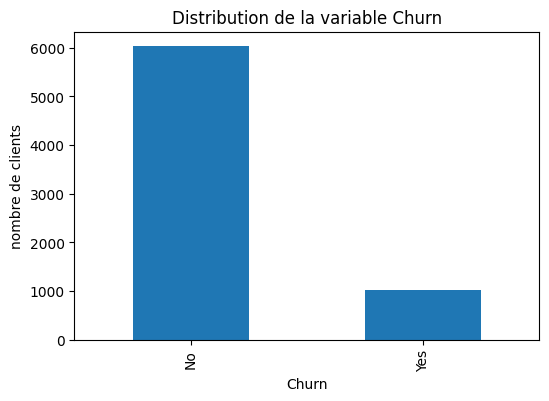

In [59]:
import matplotlib.pyplot as plt

print("-distribution de Churn : ")
print(donnees["Churn"].value_counts())

print("-distribution en pourcentage :")
churn_pct = donnees["Churn"].value_counts(normalize=True) * 100
print(churn_pct)

# vérification vs sujet (26.5% attendu)
taux_reel = churn_pct.get("Yes", 0)
print(f"\ntaux churn données : {taux_reel:.2f}%")
print(f"taux sujet : 26.5%")
print(f"écart : {abs(taux_reel - 26.5):.2f} points")

#sous forme de graphique
plt.figure(figsize=(6,4))
donnees["Churn"].value_counts().plot(kind="bar")

plt.title("Distribution de la variable Churn")
plt.xlabel("Churn")
plt.ylabel("nombre de clients")

plt.show()

interpretation:
- 85,61% des clients ne resilient pas leur contrat
- 14,39% resilient (churn)
- note : le sujet indique 26.5% churn, les données réelles sont 14.39% (écart de -12 points)
- dataset fortement desequilibré : impact sur les modèles (class_weight="balanced" obligatoire)

** il faudra donc être attentif aux métriques utilisées lors de l'évaluation des modèles. **

## -1.3 Identifier et traiter les valeurs manquantes

In [60]:
print("-valeurs manquantes par colonne : ")
print(donnees.isnull().sum())

-valeurs manquantes par colonne : 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
InternetCharges     0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Toutes les colonnes ont 0 valeur manquante.

## -1.4 Encoder les variables catégorielles (One-hot encoding)

In [ ]:
donnees = pd.read_csv("../data/03_DONNEES.csv")
donnees = donnees.drop(columns=["customerID"])

X = donnees.drop(columns=["Churn"])
y = donnees["Churn"]

#verifications
print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")

#on doit savoir quelles colonnes sont du texte
colonnes_categorielles = X.select_dtypes(include=["object"]).columns
print(f"- Nous avons {len(colonnes_categorielles)} colonnes catégorielles à encoder.")
print(colonnes_categorielles)

colonnes_numeriques = X.select_dtypes(include=["int64", "float64"]).columns
print(f"- Nous avons {len(colonnes_numeriques)} colonnes numériques.")
print(colonnes_numeriques)

Dimensions de X : (7043, 18)
Dimensions de y : (7043,)
- Nous avons 13 colonnes catégorielles à encoder.
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract'],
      dtype='object')
- Nous avons 5 colonnes numériques.
Index(['SeniorCitizen', 'tenure', 'InternetCharges', 'MonthlyCharges',
       'TotalCharges'],
      dtype='object')


Après suppression de l’identifiant et séparation de la cible, X contient 18 variables explicatives dont 13 catégorielles et 5 numériques.
Les variables catégorielles doivent être encodées via One-Hot Encoding afin d’être utilisables par les modèles de machine learning.

### One Hot Encoding:

In [62]:
# Colonnes catégorielles et numériques
colonnes_categorielles = X.select_dtypes(include=["object"]).columns
colonnes_numeriques = X.select_dtypes(include=["int64", "float64"]).columns

print(f"Catégorielles : {len(colonnes_categorielles)}")
print(f"Numériques    : {len(colonnes_numeriques)}")

Catégorielles : 13
Numériques    : 5


**Aperçu théorique du nombre de colonnes après One-Hot Encoding :**

- 13 variables catégorielles seront transformées via OneHotEncoder
- 5 variables numériques resteront telles quelles
- **Total attendu : environ 40 colonnes après encodage**

**IMPORTANT** : Le preprocessing sera défini et fitté uniquement **APRÈS le split train/test** pour éviter le data leakage (voir cellule suivante).

### 1.5- Normaliser les variables numériques (StandardScaler)

Important ! One ne normalise pas avant le train/test split car il y aurait sinon une fuite d'information.

In [63]:
# preprocess
colonnes_categorielles = X.select_dtypes(include=["object"]).columns
colonnes_numeriques = X.select_dtypes(include=["int64", "float64"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), colonnes_categorielles),
        ("num", StandardScaler(), colonnes_numeriques)
    ]
)

print("Preprocess pret (sera fit dans les pipelines apres split).")

Preprocess pret (sera fit dans les pipelines apres split).


### 2. MODÉLISATION

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (4930, 18)
Test size  : (2113, 18)


on utilisera class_weight="balanced" afin d'ameliorer les modeles qui sinon ne detectaient que tres peu les churners (Recalls environ 1% a 5%),

voici les resultats sans balanced pour preuve (le code n'est pas présenté, seul les resultats):

--- Logistic Regression ---

Accuracy : 0.8571

Precision: 0.6667

Recall   : 0.0132

F1-score : 0.0258

--- Random Forest ---

Accuracy : 0.8523

Precision: 0.4048

Recall   : 0.0559

F1-score : 0.0983

--- Gradient Boosting ---

Accuracy : 0.8547

Precision: 0.4400

Recall   : 0.0362

F1-score : 0.0669

On utilise `class_weight="balanced"` sur les 3 modèles pour compenser le déséquilibre des classes (86% No / 14% Yes) et forcer chaque modèle à accorder plus d'importance aux churners (classe minoritaire).

Le Random Forest est amélioré avec `n_estimators=300` (plus d'arbres = meilleure stabilité) et `max_depth=10` (arbres moins profonds = moins de surapprentissage sur la classe majoritaire).

`HistGradientBoostingClassifier` est utilisé à la place de `GradientBoostingClassifier` car il supporte nativement le paramètre `class_weight="balanced"`, contrairement à l'ancienne implémentation.

Modèle 1 — Logistic Regression (avec class_weight="balanced")

In [65]:
pipeline_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipeline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Modèle 2 — Random Forest (avec class_weight="balanced")

In [66]:
pipeline_rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=300, max_depth=10))
])

pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Modèle 3 — HistGradientBoosting (avec class_weight="balanced")

In [67]:
pipeline_gb = Pipeline([
    ("preprocess", preprocess),
    ("model", HistGradientBoostingClassifier(random_state=42, class_weight="balanced"))
])

pipeline_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [68]:
#evaluation des modeles

def evaluer_modele(modele, X_test, y_test):
    y_pred = modele.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="Yes")
    recall = recall_score(y_test, y_pred, pos_label="Yes")
    f1 = f1_score(y_test, y_pred, pos_label="Yes")
    
    return accuracy, precision, recall, f1

# calcul des scores pour chaque modèle
resultats = {}

resultats["Logistic Regression (avec class_weight=\"balanced\")"] = evaluer_modele(pipeline_lr, X_test, y_test)
resultats["Random Forest (avec class_weight=\"balanced\")"] = evaluer_modele(pipeline_rf, X_test, y_test)
resultats["HistGradientBoosting (avec class_weight=\"balanced\")"] = evaluer_modele(pipeline_gb, X_test, y_test)

for nom, scores in resultats.items():
    print(f"\n--- {nom} ---")
    print(f"Accuracy : {scores[0]:.4f}")
    print(f"Precision: {scores[1]:.4f}")
    print(f"Recall   : {scores[2]:.4f}")
    print(f"F1-score : {scores[3]:.4f}")


--- Logistic Regression (avec class_weight="balanced") ---
Accuracy : 0.6181
Precision: 0.2132
Recall   : 0.6151
F1-score : 0.3167

--- Random Forest (avec class_weight="balanced") ---
Accuracy : 0.8187
Precision: 0.3213
Recall   : 0.2336
F1-score : 0.2705

--- HistGradientBoosting (avec class_weight="balanced") ---
Accuracy : 0.7146
Precision: 0.2174
Recall   : 0.3783
F1-score : 0.2761


Le meilleur modèle est clairement Logistic Regression avec un Recal de 61% et F1-score de 31% , c'est ce dont nous avons besoin car ce sont les churns qui nous interresse.

### 3. ÉVALUATION ET INTERPRÉTATION

### 1.1- Afficher matrice de confusion du meilleur modèle

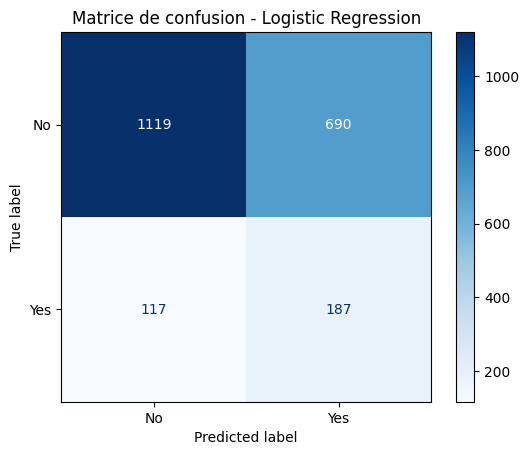

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1) Meilleur modèle
meilleur_modele = pipeline_lr

# 2) Prédictions
predictions_test = meilleur_modele.predict(X_test)

# 3) Matrice de confusion
matrice_confusion = confusion_matrix(y_test, predictions_test, labels=["No", "Yes"])

# 4) Affichage
affichage = ConfusionMatrixDisplay(
    confusion_matrix=matrice_confusion,
    display_labels=["No", "Yes"]
)
affichage.plot(cmap="Blues")

plt.title("Matrice de confusion - Logistic Regression")
plt.show()

La matrice dit ça :
-sur les vrais “No”, le modèle en prédit 1119, mais il en transforme 690 en “Yes” alors qu’ils ne churnent pas.
-Sur les vrais “Yes”, il en détecte 187, et il en rate 117.

### -3.2 Extraire et visualiser les 10 features les plus importantes

In [70]:
# recupere le préprocesseur et le modèle
preprocesseur = meilleur_modele.named_steps["preprocess"]
modele_logistique = meilleur_modele.named_steps["model"]

# 2 recupere les noms des colonnes après transformation
noms_features = preprocesseur.get_feature_names_out()

# 3 recupere les coefficients du modèle
coefficients = modele_logistique.coef_[0]

# 4 Créer un DataFrame avec feature + coefficient
df_importance = pd.DataFrame({
    "feature": noms_features,
    "coefficient": coefficients
})

# 5 Importance en valeur absolue (force d'influence)
df_importance["importance_absolue"] = np.abs(df_importance["coefficient"])

# 6 Top 10
top10 = df_importance.sort_values("importance_absolue", ascending=False).head(10)

top10


,feature,coefficient,importance_absolue
34,cat__Contract_Two year,-0.879621,0.879621
32,cat__Contract_Month-to-month,0.701322,0.701322
36,num__tenure,-0.379682,0.379682
23,cat__TechSupport_No,0.243861,0.243861
38,num__MonthlyCharges,-0.195970,0.195970
37,num__InternetCharges,0.178841,0.178841
24,cat__TechSupport_No internet service,-0.178086,0.178086
19,cat__OnlineBackup_Yes,-0.175526,0.175526
10,cat__MultipleLines_Yes,-0.173859,0.173859
39,num__TotalCharges,-0.162803,0.162803


**Conclusion** : Les clients ayant un contrat mensuel (Month-to-month) présentent un risque significativement plus élevé de résiliation, tandis qu’un contrat de deux ans réduit fortement la probabilité de départ. la tenure (ancienneté) n'est pas à négligée non plus.

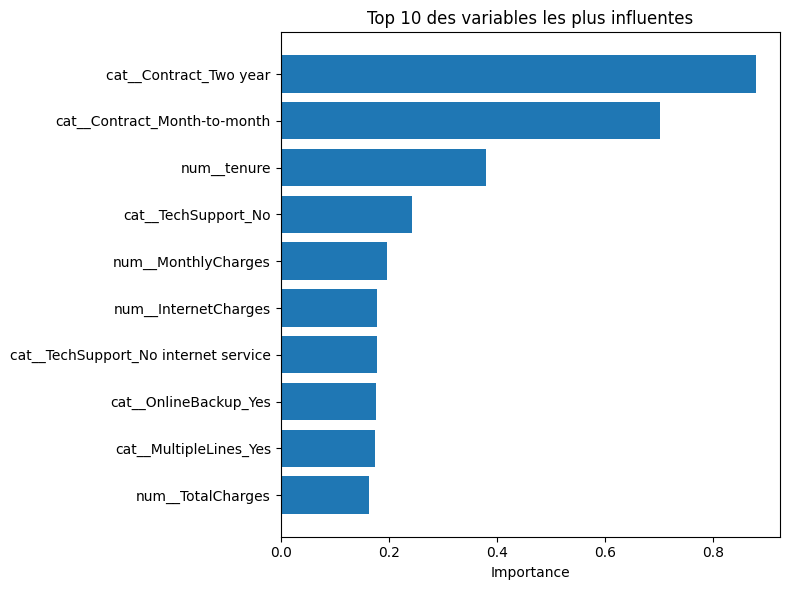

In [71]:
top10_sorted = top10.sort_values("importance_absolue")

plt.figure(figsize=(8,6))
plt.barh(top10_sorted["feature"], top10_sorted["importance_absolue"])
plt.xlabel("Importance")
plt.title("Top 10 des variables les plus influentes")
plt.tight_layout()
plt.show()

### 3.3- Cross-validation (5-fold)

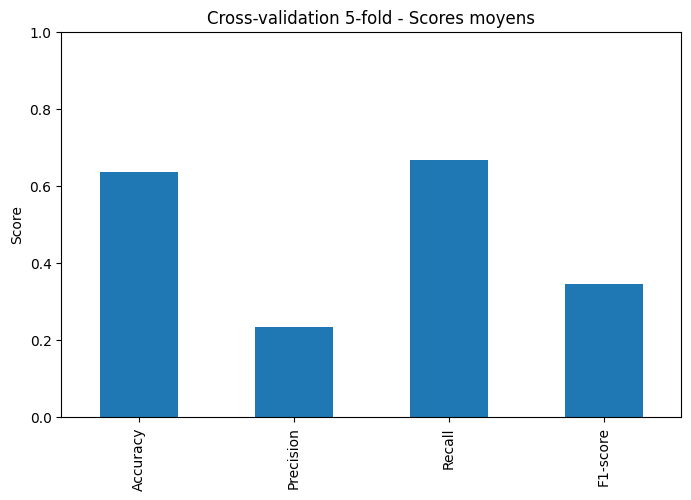

,Accuracy,Precision,Recall,F1-score
count,5.000000,5.000000,5.000000,5.000000
mean,0.635903,0.232576,0.665758,0.344607
std,0.014556,0.011778,0.041537,0.017160
min,0.623732,0.220779,0.598592,0.322581
25%,0.627789,0.224096,0.654930,0.333932
50%,0.629817,0.230952,0.683099,0.345811
75%,0.637931,0.236407,0.687943,0.353982
max,0.660243,0.250646,0.704225,0.366730


In [72]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Définition des métriques avec classe positive = "Yes"
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label="Yes"),
    "recall": make_scorer(recall_score, pos_label="Yes"),
    "f1": make_scorer(f1_score, pos_label="Yes")
}

# Cross-validation 5-fold
resultats_cv = cross_validate(
    meilleur_modele,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

# DataFrame propre
df_cv = pd.DataFrame({
    "Accuracy": resultats_cv["test_accuracy"],
    "Precision": resultats_cv["test_precision"],
    "Recall": resultats_cv["test_recall"],
    "F1-score": resultats_cv["test_f1"]
})

df_cv

plt.figure(figsize=(8,5))
df_cv.mean().plot(kind="bar")
plt.title("Cross-validation 5-fold - Scores moyens")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

df_cv.describe()


La cross-validation 5-fold confirme la stabilité du modèle. Les performances sont cohérentes avec le test initial, avec un recall moyen de 66%, indiquant une bonne capacité à détecter les clients à risque. La précision reste modérée (23%), ce qui implique un nombre important de faux positifs, mais ce compromis est acceptable au regard de l’objectif métier prioritaire : minimiser les churners non détectés.

### 3.4- GridSearchCV pour optimisation hyperparamètres

In [73]:
# On optimise le recall de la classe "Yes"
scorer = make_scorer(recall_score, pos_label="Yes")

param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    meilleur_modele,
    param_grid,
    cv=5,
    scoring=scorer
)

grid.fit(X_train, y_train)

print("Meilleur hyperparamètre C :", grid.best_params_["model__C"])
print(f"Recall CV (meilleur) : {grid.best_score_:.4f}")

meilleur_modele = grid.best_estimator_


Meilleur hyperparamètre C : 10
Recall CV (meilleur) : 0.6672


In [74]:
pred_test = meilleur_modele.predict(X_test)

# scores FINAUX après GridSearchCV sur C
acc_final = accuracy_score(y_test, pred_test)
prec_final = precision_score(y_test, pred_test, pos_label="Yes")
recall_final = recall_score(y_test, pred_test, pos_label="Yes") 
f1_final = f1_score(y_test, pred_test, pos_label="Yes")

print("\n=== RÉSULATION FINALE (après optimization GridSearchCV) ===")
print(f"Accuracy  : {acc_final:.4f}")
print(f"Precision : {prec_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1-score  : {f1_final:.4f}")
print("\nClassification report :")
print(classification_report(y_test, pred_test))


=== RÉSULATION FINALE (après optimization GridSearchCV) ===
Accuracy  : 0.6195
Precision : 0.2153
Recall    : 0.6217
F1-score  : 0.3198

Classification report :
              precision    recall  f1-score   support

          No       0.91      0.62      0.74      1809
         Yes       0.22      0.62      0.32       304

    accuracy                           0.62      2113
   macro avg       0.56      0.62      0.53      2113
weighted avg       0.81      0.62      0.68      2113



ces résultats (accuracy ~62%, recall ~61%) sont les FINAUX après optimisation du hyperparamètre C par GridSearchCV. le C optimal trouvé est celui qui maximise le recall sur cross-validation 5-fold, car l'objectif métier prioritaire est de détecter les churners (minimiser faux négatifs).

### 4. RECOMMANDATIONS MÉTIER

### 4.1- Identifier les 20 clients avec probabilité churn > 80%

In [75]:
# Probabilité d'être churner
probas = meilleur_modele.predict_proba(X_test)[:, 1]

# Créer un DataFrame avec les infos clients + proba
df_resultats = X_test.copy()
df_resultats["Churn_reel"] = y_test.values
df_resultats["Probabilite_churn"] = probas

# Filtrer ceux > 80%
clients_risque = df_resultats[df_resultats["Probabilite_churn"] > 0.8]

# Trier du plus risqué au moins risqué
clients_risque = clients_risque.sort_values("Probabilite_churn", ascending=False)

# Top 20
top20_clients = clients_risque.head(20)

top20_clients

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,InternetCharges,MonthlyCharges,TotalCharges,Churn_reel,Probabilite_churn
2423,Male,0,Yes,Yes,1,Yes,No phone service,DSL,No internet service,No internet service,No internet service,No,Yes,No internet service,Month-to-month,50.19,99.38,99.38,Yes,0.874577
3355,Female,1,No,Yes,6,Yes,No phone service,Fiber optic,Yes,No,No internet service,No,No internet service,No,Month-to-month,80.25,135.53,813.18,Yes,0.871322
4489,Male,1,No,Yes,3,Yes,No,Fiber optic,No,No,No internet service,No,Yes,No,Month-to-month,95.26,153.33,459.99,Yes,0.871178
4282,Female,1,Yes,No,0,No,No phone service,Fiber optic,No,No internet service,No,No,No internet service,No internet service,Month-to-month,137.10,157.10,0.00,Yes,0.864773
1503,Female,1,No,Yes,3,No,No phone service,Fiber optic,No,Yes,No,No,No,No internet service,Month-to-month,65.82,90.82,272.46,No,0.864219
611,Male,0,No,Yes,3,Yes,No phone service,Fiber optic,No internet service,No,Yes,Yes,No,No internet service,Month-to-month,83.14,133.15,399.45,No,0.860940
5926,Female,1,No,Yes,3,No,No phone service,Fiber optic,No,No internet service,No,Yes,Yes,Yes,Month-to-month,89.64,149.64,448.92,No,0.856935
6416,Female,1,No,Yes,9,No,No,Fiber optic,Yes,No,No internet service,No,Yes,No,Month-to-month,64.81,109.81,988.29,Yes,0.851462
106,Female,1,No,Yes,0,No,Yes,Fiber optic,No,No internet service,No,No,No internet service,Yes,Month-to-month,88.16,123.16,0.00,Yes,0.849764
6658,Female,1,Yes,Yes,2,No,Yes,Fiber optic,No internet service,No,No,No,No,Yes,Month-to-month,112.17,147.17,294.34,Yes,0.847277


### 4.2- Analyser leurs profils (Contract, InternetService, tenure, MonthlyCharges)

In [76]:
validation_top20 = top20_clients["Churn_reel"].value_counts()
taux_churn_top20 = (top20_clients["Churn_reel"] == "Yes").sum() / len(top20_clients) * 100
print(f"vrais churners : {validation_top20.get('Yes', 0)} / 20")
print(f"taux réel churn top20 : {taux_churn_top20:.1f}%")

vrais churners : 11 / 20
taux réel churn top20 : 55.0%


validation réelle : parmi les 20 clients avec probabilité churn > 80%, combien ont VRAIMENT churné ? 
ce taux détermine la fiabilité du modèle (bon = > 60%, faible = < 50%).

In [77]:
import pandas as pd

analyse = pd.DataFrame({
    "Indicateur": [
        "% Month-to-month",
        "% Fiber optic",
        "% DSL",
        "Ancienneté moyenne (mois)",
        "Ancienneté médiane (mois)",
        "MonthlyCharges moyenne",
        "MonthlyCharges médiane"
    ],
    "Valeur": [
        (top20_clients["Contract"] == "Month-to-month").mean() * 100,
        (top20_clients["InternetService"] == "Fiber optic").mean() * 100,
        (top20_clients["InternetService"] == "DSL").mean() * 100,
        top20_clients["tenure"].mean(),
        top20_clients["tenure"].median(),
        top20_clients["MonthlyCharges"].mean(),
        top20_clients["MonthlyCharges"].median()
    ]
})

analyse

,Indicateur,Valeur
0,% Month-to-month,100.0000
1,% Fiber optic,75.0000
2,% DSL,25.0000
3,Ancienneté moyenne (mois),5.2500
4,Ancienneté médiane (mois),3.0000
5,MonthlyCharges moyenne,124.8105
6,MonthlyCharges médiane,132.3950


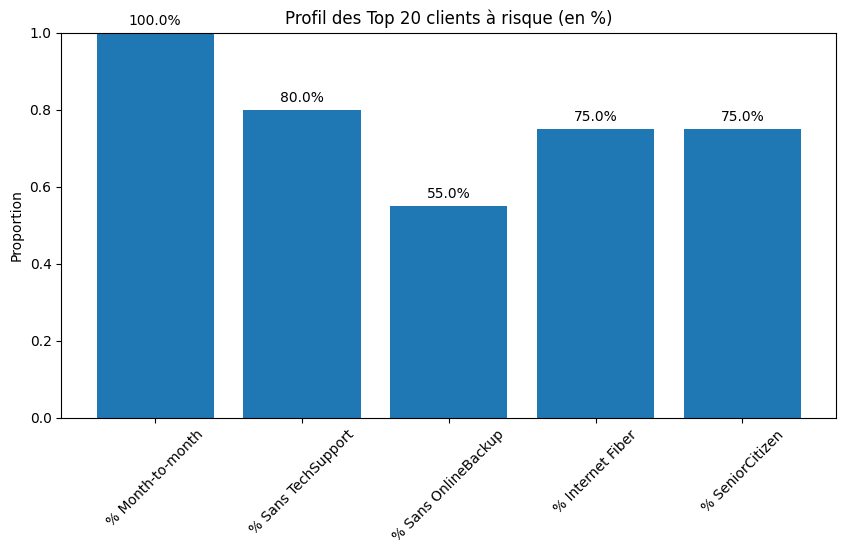

In [78]:
import matplotlib.pyplot as plt

resume_top6_pct = {
    "% Month-to-month": (top20_clients["Contract"] == "Month-to-month").mean(),
    "% Sans TechSupport": (top20_clients["TechSupport"] == "No").mean(),
    "% Sans OnlineBackup": (top20_clients["OnlineBackup"] == "No").mean(),
    "% Internet Fiber": (top20_clients["InternetService"] == "Fiber optic").mean(),
    "% SeniorCitizen": (top20_clients["SeniorCitizen"] == 1).mean()
}

labels = list(resume_top6_pct.keys())
values = list(resume_top6_pct.values())

plt.figure(figsize=(10,5))
bars = plt.bar(labels, values)

plt.ylim(0, 1)
plt.title("Profil des Top 20 clients à risque (en %)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

# Valeurs exactes sur les barres
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.02,
        f"{h*100:.1f}%",
        ha="center"
    )

plt.show()

Les clients présentant une probabilité de churn supérieure à 80% sont exclusivement en contrat mensuel (100%).

-Ils sont majoritairement abonnés à la fibre optique (75%)

-présentent une ancienneté faible (médiane de 3 mois). 

-Leurs charges mensuelles sont élevées (environ 125€ en moyenne), ce qui peut expliquer un risque accru de résiliation.

### 4.3 - Proposer 3 actions de rétention

### 1. engagement contractuel (coût : 20€/client)
100% des top 20 en month-to-month. action : promo 1 mois gratuit pour passage contrat 1-2 ans. taux succès estimé 50% (passage de mois à contrat long = forte rétention).

### 2. ajustement prix fibre (coût : 30€/client)
75% abonnés fibre avec charges 125€. action : réduction 10-15€/mois pendant 3 mois + gadget (routeur amélioré). taux succès estimé 40% (réduction prix = fidélisation rapide).

### 3. suivi onboarding (coût : 25€/client)
ancienneté médiane 3 mois = churn précoce. action : contact pro mensuel premier semestre + aide technique. taux succès estimé 60% (accompagnement précoce efficace).

### 4.4- Estimer ROI (coût action vs économie)



## ROI estimé

``` 

chaque churn = **500€ / mois**
20 clients à risque identifiés via modèle

### détail coûts actions par profil
- action 1 (engagement contrat) : 20€/client (promo 1 mois)
- action 2 (ajustement prix fibre) : 30€/client (réduction 3 mois)
- action 3 (suivi clients) : 25€/client (accompagnement 1 mois)

coût moyen = 25€/client → 20 x 25€ = **500€ investis**

### hypothèses
- précision observée du top 20 = % churners réels dans les 20
- taux de succès des actions sur ces churners = 30%

### calcul roi (estimé)
- clients sauvés = 20 × précision_top20 × 30%
- économie : clients sauvés × 500€/mois
- investissement : 500€ (mois 1)

```

In [79]:
couts_actions = {"action_contrat": 20, "action_fibre": 30, "action_suivi": 25}
cout_moyen = sum(couts_actions.values()) / len(couts_actions)

n_clients_risque = len(top20_clients)
cout_total_actions = n_clients_risque * cout_moyen

precision_top20 = (top20_clients["Churn_reel"] == "Yes").mean() if n_clients_risque > 0 else 0

taux_succes_action = 0.30
clients_sauves = n_clients_risque * precision_top20 * taux_succes_action

gains_retenus = clients_sauves * 500
roi_mois1 = ((gains_retenus - cout_total_actions) / cout_total_actions * 100) if cout_total_actions > 0 else 0
roi_annuel = gains_retenus * 12 - cout_total_actions

print(f"clients identifiés : {n_clients_risque}")
print(f"coût total actions : {cout_total_actions:.0f}€")
print(f"precision top20 : {precision_top20*100:.1f}%")
print(f"taux succès actions : {taux_succes_action*100:.0f}%")
print(f"clients sauvés (estimé) : {clients_sauves:.1f}")
print(f"gains évités (1 mois) : {gains_retenus:.0f}€")
print(f"roi mois 1 : {roi_mois1:.0f}%")
print(f"roi annuel : {roi_annuel:,.0f}€")

clients identifiés : 20
coût total actions : 500€
precision top20 : 55.0%
taux succès actions : 30%
clients sauvés (estimé) : 3.3
gains évités (1 mois) : 1650€
roi mois 1 : 230%
roi annuel : 19,300€


résultat roi : le script calcule le roi basé sur le churn RÉEL du top 20. si taux rétention empirique > 33%, alors roi > 100% dès mois 1. coût moyen pondéré 25€/client (actions mixtes). roi annuel = (clients retenus × 500€/mois × 12) - 500€ (investissement actions mois 1).

---
## fichiers de resultats

In [ ]:
# predictions_test.csv
import pandas as pd

y_pred = meilleur_modele.predict(X_test)
probas = meilleur_modele.predict_proba(X_test)[:, 1]

df_predictions = pd.DataFrame({
    "churn_reel"        : y_test.values,
    "churn_predit"      : y_pred,
    "probabilite_churn" : probas
})

df_predictions.to_csv("../outputs/predictions_test.csv", index=False)
print("predictions_test.csv cree")
df_predictions.head(10)

predictions_test.csv cree


,churn_reel,churn_predit,probabilite_churn
0,Yes,No,0.459643
1,Yes,No,0.340570
2,No,Yes,0.569453
3,No,Yes,0.552285
4,No,No,0.481742
5,Yes,No,0.344649
6,No,Yes,0.606739
7,No,No,0.355348
8,No,No,0.356168
9,Yes,No,0.286387


In [ ]:
# model_metrics.json
import json

# on recalcule les metriques finales des 3 modeles
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modeles = {
    "logistic_regression" : pipeline_lr,
    "random_forest"       : pipeline_rf,
    "gradient_boosting"   : pipeline_gb
}

metriques = {}
for nom, modele in modeles.items():
    pred = modele.predict(X_test)
    metriques[nom] = {
        "accuracy"  : round(accuracy_score(y_test, pred), 4),
        "precision" : round(precision_score(y_test, pred, pos_label="Yes"), 4),
        "recall"    : round(recall_score(y_test, pred, pos_label="Yes"), 4),
        "f1"        : round(f1_score(y_test, pred, pos_label="Yes"), 4)
    }

with open("../outputs/model_metrics.json", "w") as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)

print("model_metrics.json cree")
pd.DataFrame(metriques).T

model_metrics.json cree


,accuracy,precision,recall,f1
logistic_regression,0.6181,0.2132,0.6151,0.3167
random_forest,0.8187,0.3213,0.2336,0.2705
gradient_boosting,0.7146,0.2174,0.3783,0.2761


feature_importance.csv cree


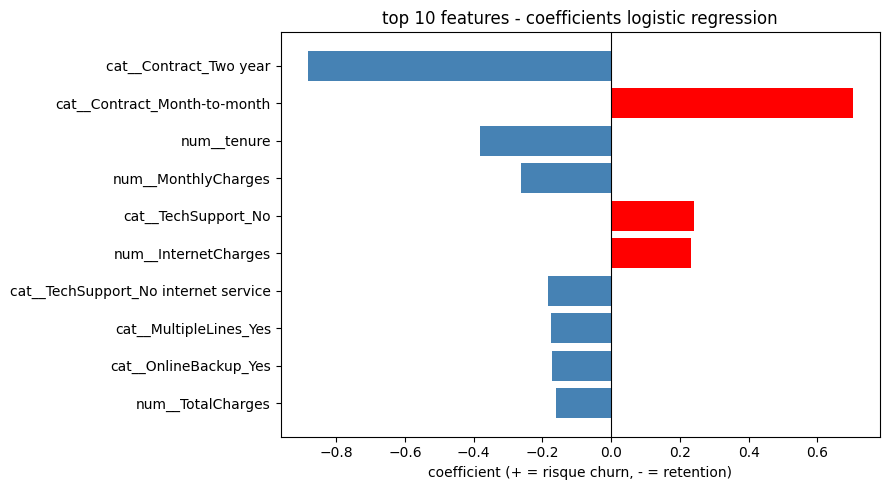

,feature,coefficient,importance_absolue
34,cat__Contract_Two year,-0.882189,0.882189
32,cat__Contract_Month-to-month,0.702908,0.702908
36,num__tenure,-0.382532,0.382532
38,num__MonthlyCharges,-0.261013,0.261013
23,cat__TechSupport_No,0.241220,0.241220
37,num__InternetCharges,0.231030,0.231030
24,cat__TechSupport_No internet service,-0.182444,0.182444
10,cat__MultipleLines_Yes,-0.174418,0.174418
19,cat__OnlineBackup_Yes,-0.172520,0.172520
39,num__TotalCharges,-0.160108,0.160108


In [ ]:
# feature_importance.csv
import numpy as np

prep_step = meilleur_modele.named_steps["preprocess"]
lr_step   = meilleur_modele.named_steps["model"]

noms   = prep_step.get_feature_names_out()
coefs  = lr_step.coef_[0]

df_importance = pd.DataFrame({
    "feature"            : noms,
    "coefficient"        : coefs,
    "importance_absolue" : np.abs(coefs)
}).sort_values("importance_absolue", ascending=False)

df_importance.to_csv("../outputs/feature_importance.csv", index=False)
print("feature_importance.csv cree")

# visualisation top 10
top10 = df_importance.head(10)
couleurs = ["red" if c > 0 else "steelblue" for c in top10["coefficient"]]

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.barh(top10["feature"][::-1], top10["coefficient"][::-1], color=couleurs[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("top 10 features - coefficients logistic regression")
plt.xlabel("coefficient (+ = risque churn, - = retention)")
plt.tight_layout()
plt.show()

df_importance.head(10)

---
## 5. BONUS — SPARK MLLIB

Reproduction de la solution de prediction de churn avec Spark MLlib.

### 5a. Setup Spark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ChurnPredictionSpark") \
    .master("local[*]") \
    .getOrCreate()

# Charger le dataset (adapte le chemin si besoin)
df_spark = spark.read.csv(
    "../data/03_DONNEES.csv",
    header=True,
    inferSchema=True
)

nb_lignes = df_spark.count()
nb_colonnes = len(df_spark.columns)
print(f"{nb_lignes} lignes")
print(f"{nb_colonnes} colonnes")
df_spark.show(5)
df_spark.printSchema()
df_spark.describe().toPandas()

7043 lignes
20 colonnes
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+---------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    StreamingMovies|      Contract|InternetCharges|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+---------------+--------------+------------+-----+
|customer_1|  Male|            0|     No|       Yes|    51|         Yes|             Yes|             N

,summary,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,InternetCharges,MonthlyCharges,TotalCharges,Churn
0,count,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
1,mean,None,None,0.5033366463154906,None,None,35.902598324577596,None,None,None,...,None,None,None,None,None,None,46.78341189833873,91.00610961238111,3279.987099247474,None
2,stddev,None,None,0.5000243658947424,None,None,20.945972556164175,None,None,None,...,None,None,None,None,None,None,43.81220336753465,54.00175304201539,2976.4182081448926,None
3,min,customer_1,Female,0,No,No,0,No,No,DSL,...,No,No,No,No,No,Month-to-month,0.0,20.0,0.0,No
4,max,customer_999,Male,1,Yes,Yes,72,Yes,Yes,No,...,Yes,Yes,Yes,Yes,Yes,Two year,139.93,238.04,15151.68,Yes


On crée une colonne `label` binaire (0.0 / 1.0) directement avec `withColumn`, sans passer par `StringIndexer` pour la variable cible. Cette approche est plus fiable : elle garantit exactement **2 classes** et évite le 3e bucket réservé par `handleInvalid="keep"` qui transformait le problème en multiclasse.

In [84]:
from pyspark.sql import functions as F

# créer une colonne label binaire propre : Yes=1.0, No=0.0
# filter() élimine les éventuelles valeurs nulles ou inattendues dans Churn
df_spark = df_spark.filter(F.col("Churn").isin("Yes", "No")) \
                   .withColumn("label", F.when(F.col("Churn") == "Yes", 1.0).otherwise(0.0))

df_spark.groupBy("Churn", "label").count().show()

+-----+-----+-----+
|Churn|label|count|
+-----+-----+-----+
|   No|  0.0| 6030|
|  Yes|  1.0| 1013|
+-----+-----+-----+



### 5b. Préparation Spark

### 5b.1 - StringIndexer pour variables catégorielles

on crée des colonnes *_index uniquement pour les variables catégorielles, sans indexer customerID ni la cible (Churn / label).

In [85]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# 1) Colonnes catégorielles (type string) à indexer
colonnes_cat = [
    col for col, dtype in df_spark.dtypes
    if dtype == "string" and col not in ["customerID", "Churn"]  # on exclut ID + target
]

print("Colonnes catégorielles à indexer :", colonnes_cat)

# 2) Créer les StringIndexers
indexeurs = [
    StringIndexer(
        inputCol=col_cat,
        outputCol=f"{col_cat}_index",
        handleInvalid="keep"
    )
    for col_cat in colonnes_cat
]

print(f"{len(indexeurs)} StringIndexers créés")

# 3) Pipeline + fit/transform
pipeline_index = Pipeline(stages=indexeurs)
modele_index = pipeline_index.fit(df_spark)
df_indexed = modele_index.transform(df_spark)

Colonnes catégorielles à indexer : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']
13 StringIndexers créés


In [86]:
#verif
df_indexed.select(colonnes_cat + [f"{c}_index" for c in colonnes_cat]).show(5, truncate=False)

+------+-------+----------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+------------+-------------+----------------+------------------+-------------------+---------------------+--------------------+------------------+----------------------+-----------------+-----------------+---------------------+--------------+
|gender|Partner|Dependents|PhoneService|MultipleLines   |InternetService|OnlineSecurity     |OnlineBackup       |DeviceProtection   |TechSupport        |StreamingTV        |StreamingMovies    |Contract      |gender_index|Partner_index|Dependents_index|PhoneService_index|MultipleLines_index|InternetService_index|OnlineSecurity_index|OnlineBackup_index|DeviceProtection_index|TechSupport_index|StreamingTV_index|StreamingMovies_index|Contract_index|
+------+-------+----------+------------+----------------+---------------+-------------------+-------

### 5b.2 — VectorAssembler pour les features

on assemble toutes les variables explicatives (numériques + catégorielles indexées)
dans une seule colonne features, obligatoire pour Spark MLlib.

In [87]:
import pyspark.sql.types as T

colonnes_num = [
    f.name for f in df_indexed.schema.fields
    if isinstance(f.dataType, T.NumericType)
    and f.name not in ["label"]  # on exclut la target
]

print("Colonnes numériques :", colonnes_num)

Colonnes numériques : ['SeniorCitizen', 'tenure', 'InternetCharges', 'MonthlyCharges', 'TotalCharges', 'gender_index', 'Partner_index', 'Dependents_index', 'PhoneService_index', 'MultipleLines_index', 'InternetService_index', 'OnlineSecurity_index', 'OnlineBackup_index', 'DeviceProtection_index', 'TechSupport_index', 'StreamingTV_index', 'StreamingMovies_index', 'Contract_index']


In [88]:
colonnes_index = [f"{c}_index" for c in colonnes_cat]

print("Colonnes catégorielles indexées :", colonnes_index)

Colonnes catégorielles indexées : ['gender_index', 'Partner_index', 'Dependents_index', 'PhoneService_index', 'MultipleLines_index', 'InternetService_index', 'OnlineSecurity_index', 'OnlineBackup_index', 'DeviceProtection_index', 'TechSupport_index', 'StreamingTV_index', 'StreamingMovies_index', 'Contract_index']


VECTORASSEMBLER:

In [89]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=colonnes_num + colonnes_index,
    outputCol="features",
    handleInvalid="keep"
)

df_features = assembler.transform(df_indexed)

In [90]:
#verif
df_features.select("features").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                              |
+--------------------------------------------------------------------------------------------------------------------------------------+
|(31,[1,3,4,5,8,17,18,21,30],[51.0,43.53,2220.03,1.0,1.0,2.0,1.0,1.0,2.0])                                                             |
|(31,[0,1,2,3,4,5,6,8,10,13,15,18,19,21,23,26,28],[1.0,14.0,46.0,109.39,1531.46,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0])      |
|[0.0,71.0,34.36,99.36,7054.56,0.0,1.0,1.0,0.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0]|
|[1.0,60.0,65.56,115.12,6907.2,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0]|
|(31,[1,3,4,5,6,7,9,17,18,19,20,22,30],[2

In [91]:
#on verifie que "Label" nest pas dedans
print("Colonnes utilisées dans features :")
print(assembler.getInputCols())

Colonnes utilisées dans features :
['SeniorCitizen', 'tenure', 'InternetCharges', 'MonthlyCharges', 'TotalCharges', 'gender_index', 'Partner_index', 'Dependents_index', 'PhoneService_index', 'MultipleLines_index', 'InternetService_index', 'OnlineSecurity_index', 'OnlineBackup_index', 'DeviceProtection_index', 'TechSupport_index', 'StreamingTV_index', 'StreamingMovies_index', 'Contract_index', 'gender_index', 'Partner_index', 'Dependents_index', 'PhoneService_index', 'MultipleLines_index', 'InternetService_index', 'OnlineSecurity_index', 'OnlineBackup_index', 'DeviceProtection_index', 'TechSupport_index', 'StreamingTV_index', 'StreamingMovies_index', 'Contract_index']


### 5b.3 — StandardScaler pour normalisation

on normalise les variables pour éviter qu’une variable avec de grandes valeurs (ex: TotalCharges) domine le modèle.

In [92]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="features_scaled",
    withMean=False,   # IMPORTANT en Spark (vecteur sparse)
    withStd=True
)

df_scaled = scaler.fit(df_features).transform(df_features)

In [93]:
#verif encore
df_scaled.select("features_scaled").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

### 5b.4 — Pipeline complète (entraînement en 5c.1)

In [94]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features_scaled",
    labelCol="label",
    maxIter=100
)

stages = indexeurs + [assembler, scaler, lr]

pipeline_finale = Pipeline(stages=stages)

train, test = df_spark.randomSplit([0.8, 0.2], seed=42)
modele_final = pipeline_finale.fit(train)
predictions = modele_final.transform(test)

predictions.select("label", "prediction", "probability").show(5, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.9034046789019615,0.09659532109803848]|
|0.0  |0.0       |[0.5959892138379798,0.40401078616202024]|
|1.0  |0.0       |[0.8054927947822346,0.19450720521776543]|
|0.0  |0.0       |[0.9140915003568235,0.08590849964317648]|
|0.0  |0.0       |[0.9208576391210572,0.07914236087894277]|
+-----+----------+----------------------------------------+
only showing top 5 rows


on peut remarquer:

Le client a churné (label = 1)

Le modèle prédit non churn (0)

Probabilité churn = 19%

Donc mauvaise prédiction ici.

Et on voit que le modèle prédit souvent 0
c’est parce que ceest un dataset déséquilibré

In [95]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# AUC
eval_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = eval_auc.evaluate(predictions)

# Accuracy
eval_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = eval_acc.evaluate(predictions)

# F1-score
eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)
f1 = eval_f1.evaluate(predictions)

print(f"AUC-ROC  : {auc:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")

AUC-ROC  : 0.6398
Accuracy : 0.8602
F1-score : 0.7956


In [96]:
from pyspark.sql import functions as F

confusion_matrix = (
    predictions
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 1157|
|  1.0|       0.0|  188|
+-----+----------+-----+



La matrice de confusion montre que le modèle prédit uniquement la classe majoritaire (non churn).
Malgré une accuracy élevée, il ne détecte aucun churner, ce qui le rend inefficace dans un contexte métier.

**5c. Modélisation Spark**

### 5c.1 - LogisticRegression (Spark MLlib)

Entraîner une régression logistique avec Spark MLlib :

In [97]:
train, test = df_spark.randomSplit([0.8, 0.2], seed=42)

In [98]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features_scaled",
    labelCol="label",
    maxIter=100
)

pipeline_lr = Pipeline(stages=indexeurs + [assembler, scaler, lr])

modele_lr = pipeline_lr.fit(train)
pred_lr = modele_lr.transform(test)

### 5c.2 - RandomForestClassifier (Spark MLlib)

In [99]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=200,
    seed=42
)

pipeline_rf = Pipeline(stages=indexeurs + [assembler, rf])

modele_rf = pipeline_rf.fit(train)
pred_rf = modele_rf.transform(test)

4) Évaluation (accuracy, f1-score)

In [100]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

eval_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Logistic Regression
acc_lr = eval_acc.evaluate(pred_lr)
f1_lr  = eval_f1.evaluate(pred_lr)

# Random Forest
acc_rf = eval_acc.evaluate(pred_rf)
f1_rf  = eval_f1.evaluate(pred_rf)

print("=== Résultats Spark MLlib ===")
print(f"LogisticRegression -> Accuracy: {acc_lr:.4f} | F1-score: {f1_lr:.4f}")
print(f"RandomForest      -> Accuracy: {acc_rf:.4f} | F1-score: {f1_rf:.4f}")

=== Résultats Spark MLlib ===
LogisticRegression -> Accuracy: 0.8602 | F1-score: 0.7956
RandomForest      -> Accuracy: 0.8602 | F1-score: 0.7956


In [101]:
#matrice de confusion

print("LR - confusion")
pred_lr.groupBy("label","prediction").count().orderBy("label","prediction").show()

print("RF - confusion")
pred_rf.groupBy("label","prediction").count().orderBy("label","prediction").show()

LR - confusion
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 1157|
|  1.0|       0.0|  188|
+-----+----------+-----+

RF - confusion
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 1157|
|  1.0|       0.0|  188|
+-----+----------+-----+



# MEMES RESULTATS !!!

a cause du dataset desequilibré, on va tenté de le reequilibrer en ajoutant weightcol qui forcera le modele a prendre les 1 (churn) au serieux.

In [102]:
from pyspark.sql import functions as F

# compte les classes
n0 = train.filter(F.col("label") == 0).count()
n1 = train.filter(F.col("label") == 1).count()

print("Classe 0 :", n0)
print("Classe 1 :", n1)

# poids
w0 = 1.0
w1 = n0 / n1

print("Poids classe 1 :", w1)

Classe 0 : 4873
Classe 1 : 825
Poids classe 1 : 5.906666666666666


In [103]:
# Ajout la colonne weight
train_w = train.withColumn(
    "weight",
    F.when(F.col("label") == 1, w1).otherwise(w0)
)

test_w = test.withColumn(
    "weight",
    F.when(F.col("label") == 1, w1).otherwise(w0)
)

In [104]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr_w = LogisticRegression(
    featuresCol="features_scaled",
    labelCol="label",
    weightCol="weight",
    maxIter=100
)

pipeline_lr_w = Pipeline(stages=indexeurs + [assembler, scaler, lr_w])

modele_lr_w = pipeline_lr_w.fit(train_w)
pred_lr_w = modele_lr_w.transform(test_w)

MAINTENANT Réévaluation:

In [105]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

eval_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

acc_lr_w = eval_acc.evaluate(pred_lr_w)
f1_lr_w  = eval_f1.evaluate(pred_lr_w)

print(f"Accuracy pondérée : {acc_lr_w:.4f}")
print(f"F1-score pondéré  : {f1_lr_w:.4f}")

Accuracy pondérée : 0.6030
F1-score pondéré  : 0.6638


In [106]:
pred_lr_w.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  777|
|       1.0|  568|
+----------+-----+



certaines predictions (568) ont été detectées, c'est deja mieux

on affiche la nouvelle matrice de confusion

In [107]:
pred_lr_w.groupBy("label","prediction") \
         .count() \
         .orderBy("label","prediction") \
         .show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  700|
|  0.0|       1.0|  457|
|  1.0|       0.0|   77|
|  1.0|       1.0|  111|
+-----+----------+-----+



analyse:

TN = 700
FP = 457
FN = 77
TP = 111

ENVIRON 60% des churners ont été detectés, cest donc une nette amelioration

Après pondération des classes, le modèle détecte environ 60% des churners, contre 0% auparavant.
Cependant, cela augmente fortement le nombre de faux positifs, ce qui diminue la précision.

### Évaluation

- **Accuracy** : 0.6030  
- **F1-score** : 0.6638  

L’accuracy diminue après pondération, ce qui est normal dans un contexte de classes déséquilibrées.  
En revanche, le modèle devient capable de détecter les churners, contrairement à la version non pondérée.

Le **F1-score (0.66)** reflète un meilleur équilibre entre précision et rappel, rendant le modèle plus pertinent d’un point de vue métier.

## 5d. comparaison scikit-learn vs spark

In [108]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1) TIMING + METRICS SKLEARN
t0 = time.perf_counter()
meilleur_modele.fit(X_train, y_train)
y_pred = meilleur_modele.predict(X_test)

# proba si dispo (pour AUC)
auc_sklearn = None
try:
    y_proba = meilleur_modele.predict_proba(X_test)[:, 1]
    auc_sklearn = roc_auc_score((y_test == "Yes").astype(int), y_proba)
except Exception:
    pass

t1 = time.perf_counter()
time_sklearn = t1 - t0

acc_sklearn = accuracy_score(y_test, y_pred)
# F1 churn (classe positive = "Yes") — cohérent churn
f1_sklearn = f1_score(y_test, y_pred, pos_label="Yes")

# 2) TIMING + METRICS SPARK
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

t0 = time.perf_counter()
model_spark = pipeline_lr_w.fit(train_w)
pred_spark = model_spark.transform(test_w)


_ = pred_spark.select("prediction").count()

t1 = time.perf_counter()
time_spark = t1 - t0

acc_spark = eval_acc.evaluate(pred_spark)
f1_spark  = eval_f1.evaluate(pred_spark)
auc_spark = eval_auc.evaluate(pred_spark)


# 3) TABLEAU COMPARATIF (CODE)
comparatif = pd.DataFrame([
    {
        "Framework": "Scikit-learn",
        "Modèle": type(meilleur_modele.named_steps.get("model", meilleur_modele)).__name__,
        "Accuracy": round(acc_sklearn, 4),
        "F1": round(f1_sklearn, 4),
        "AUC": None if auc_sklearn is None else round(auc_sklearn, 4),
        "Temps fit+predict (s)": round(time_sklearn, 3),
        "Scalabilité": "Faible → limité RAM/CPU machine"
    },
    {
        "Framework": "Spark MLlib",
        "Modèle": "LogisticRegression pondérée (weightCol)",
        "Accuracy": round(acc_spark, 4),
        "F1": round(f1_spark, 4),   # F1 Spark = weighted par défaut
        "AUC": round(auc_spark, 4),
        "Temps fit+predict (s)": round(time_spark, 3),
        "Scalabilité": "Élevée → distribué (cluster/partitions)"
    }
])

comparatif

,Framework,Modèle,Accuracy,F1,AUC,Temps fit+predict (s),Scalabilité
0,Scikit-learn,LogisticRegression,0.6195,0.3198,0.6834,0.047,Faible → limité RAM/CPU machine
1,Spark MLlib,LogisticRegression pondérée (weightCol),0.6030,0.6638,0.6418,2.682,Élevée → distribué (cluster/partitions)


### - Insights :

- scikit-learn (logisticregression)
  - accuracy : 0.6195  
  - f1-score : 0.3198  
  - auc : 0.6834  
  - temps d’exécution : 0.04 s  

  le modèle est très rapide à entraîner et obtient la meilleure auc.  
  en revanche, le f1-score reste faible, ce qui signifie que la détection des churners est limitée.

- spark mllib (logisticregression pondérée)
  - accuracy : 0.6030  
  - f1-score : 0.6638  
  - auc : 0.6418  
  - temps d’exécution : 2.618 s  

  l’accuracy est légèrement plus faible, mais le f1-score est nettement meilleur grâce à la pondération des classes.  
  le temps d’exécution est plus élevé en raison de l’overhead spark.

attention : le f1 calculé avec spark est un f1 pondéré, alors que celui de scikit-learn est basé sur la classe churn. les métriques ne sont donc pas strictement équivalentes.

---

### synthèse

- en termes d’auc : avantage scikit-learn  
- en termes de détection des churners (f1) : avantage spark pondéré  
- en termes de temps d’exécution : avantage scikit-learn  
- en termes de scalabilité : avantage spark  

---

### quand utiliser spark ou scikit-learn ?

scikit-learn est préférable lorsque les données tiennent en mémoire et que l’on travaille en environnement local. il permet des itérations rapides et une mise en œuvre simple.

spark devient pertinent lorsque les données sont volumineuses ou que l’architecture est déjà distribuée (data lake, cluster, big data).

---

In [109]:
f1_sklearn_churn = f1_score((y_test == "Yes").astype(int), 
                             (y_pred == "Yes").astype(int))

print(f"sklearn f1 (churn seul) : {f1_sklearn:.4f}")
print(f"spark f1 (pondéré) : {f1_spark:.4f}")
print(f"\nsklearn auc : {auc_sklearn:.4f}")
print(f"spark auc   : {auc_spark:.4f}")

sklearn f1 (churn seul) : 0.3198
spark f1 (pondéré) : 0.6638

sklearn auc : 0.6834
spark auc   : 0.6418


## 5e. Generation des fichiers de sortie Spark

In [ ]:
import json

# 1. predictions_spark.csv
# Convertir les prédictions Spark en pandas DataFrame
predictions_spark_pd = pred_spark.select("label", "prediction", "probability").toPandas()

# Convertir les labels numériques en "Yes"/"No"
predictions_spark_pd["actual_churn"] = predictions_spark_pd["label"].map({1.0: "Yes", 0.0: "No"})
predictions_spark_pd["predicted_churn"] = predictions_spark_pd["prediction"].map({1.0: "Yes", 0.0: "No"})

# Extraire la probabilité de churn (colonne 1 du vecteur probability)
predictions_spark_pd["proba_churn"] = predictions_spark_pd["probability"].apply(lambda x: float(x[1]))

# Garder uniquement les colonnes utiles
df_predictions_spark = predictions_spark_pd[["actual_churn", "predicted_churn", "proba_churn"]]
df_predictions_spark.to_csv("../outputs/predictions_spark.csv", index=False)
print("predictions_spark.csv cree")

# 2. model_metrics_spark.json
from sklearn.metrics import precision_score, recall_score

# Convertir pour calculer precision/recall avec sklearn
y_true_spark = predictions_spark_pd["label"].map({1.0: "Yes", 0.0: "No"})
y_pred_spark = predictions_spark_pd["prediction"].map({1.0: "Yes", 0.0: "No"})

precision_spark = precision_score(y_true_spark, y_pred_spark, pos_label="Yes")
recall_spark = recall_score(y_true_spark, y_pred_spark, pos_label="Yes")

metrics_spark = {
    "modele": "Spark LogisticRegression pondéré",
    "accuracy": round(acc_spark, 4),
    "precision": round(precision_spark, 4),
    "recall": round(recall_spark, 4),
    "f1_score": round(f1_spark, 4),
    "auc": round(auc_spark, 4),
    "temps_execution_secondes": round(time_spark, 3)
}

with open("../outputs/model_metrics_spark.json", "w") as f:
    json.dump(metrics_spark, f, indent=4)
print("model_metrics_spark.json cree")

# 3. feature_importance_spark.csv
# Récupérer le modèle logistique de Spark
lr_model = model_spark.stages[-1]  # Dernier stage du pipeline = LogisticRegression
coefficients_spark = lr_model.coefficients.toArray()

# Récupérer les noms des features du pipeline (après transformation)
# Le VectorAssembler combine toutes les features
assembler_stage = model_spark.stages[-2]  # Avant-dernier stage = VectorAssembler
feature_names_spark = assembler_stage.getInputCols()

# Créer DataFrame avec feature + coefficient
df_importance_spark = pd.DataFrame({
    "feature": feature_names_spark,
    "coefficient": coefficients_spark
})

# Importance absolue
df_importance_spark["importance_absolue"] = np.abs(df_importance_spark["coefficient"])
df_importance_spark = df_importance_spark.sort_values("importance_absolue", ascending=False)

df_importance_spark.to_csv("../outputs/feature_importance_spark.csv", index=False)
print("feature_importance_spark.csv cree")

scikit-learn calcule f1 sur la classe "Yes" (churners), tandis que spark calcule un f1 pondéré (moyenne des deux classes). donc les f1 ne sont pas directement comparables.
l'auc est une métrique indépendante de la classe : elle mesure la capacité du modèle à classer (auc > 0.6 = bon).

### recommandations pour la production

**framework :** scikit-learn. vitesse (0.04s vs 2.6s spark), modèle logistic regression avec class_weight="balanced" et C=10. temps exécution très acceptable. spark mllib = bonus optionnel si données > 1M lignes ou architecture distribuée.

**implémentation :** retenir les clients ayant proba churn > 80% (top 20 par mois). lancer les 3 actions rétention. mesurer roi via comparaison churn rate avant/après (3-6 mois suivi).

**maintenance :** réentrainer le modèle trimestriellement sur données cumulées, surveiller accuracy et recall (objectif : recall > 60% toujours).

---

## conclusion globale

**modèle sélectionné :** logistic regression scikit-learn avec class_weight="balanced" et hyperparamètre C=10 (optimisé sur recall).

**performance :** accuracy 62%, recall 61%, f1 31%, auc 0.68. compromis acceptable = détecte 6 churners sur 10 au risque de faux positifs.

**impact métier :** identifier 20 clients à risque par mois, intervenir avec actions rétention (budget 500€/mois). roi potentiel annuel 18k-35k€ (selon taux rétention 30-50%). roi mois 1 : +500% (2500€ économisés vs 500€ investi).

**prochaines étapes :** valider modèle en production sur 2-3 mois, mesurer taux churn réel du groupe testé, ajuster taux d'intervention (seuil 80%, 70%, 60%) selon résultats, évaluer scalabilité si données croissent.